In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [47]:
# 1️⃣ Load dataset
# ----------------------------
url = r"C:\mechine_learning\automobile (2)\automobile\imports-85.data"  # change path if needed

cols = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
    "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width",
    "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size",
    "fuel-system", "bore", "stroke", "compression-ratio", "horsepower",
    "peak-rpm", "city-mpg", "highway-mpg", "price"
]

df = pd.read_csv(url, names=cols, na_values='?')


In [31]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [34]:
print(df["fuel-type"].unique())


['gas' 'diesel']


In [35]:
df_encoded = pd.get_dummies(df, columns=["fuel-type"], drop_first=True)


In [36]:
df_encoded

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,fuel-type_gas
0,3,NaN,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,True
1,3,NaN,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,True
2,1,NaN,alfa-romero,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,True
3,2,164.0,audi,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,True
4,2,164.0,audi,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,std,four,sedan,rwd,front,109.1,188.8,...,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0,True
201,-1,95.0,volvo,turbo,four,sedan,rwd,front,109.1,188.8,...,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0,True
202,-1,95.0,volvo,std,four,sedan,rwd,front,109.1,188.8,...,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0,True
203,-1,95.0,volvo,turbo,four,sedan,rwd,front,109.1,188.8,...,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0,False


In [38]:
X = df_encoded[["engine-size", "fuel-type_gas"]].values
y = df_encoded["price"].values


In [40]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_num = poly.fit_transform(X[:, [0]])  # only engine-size gets polynomial
X_full = np.hstack([X_num, X[:, [1]]])  # add the categorical column

model = LinearRegression()
model.fit(X_full, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
engine_size = np.array([[200]])  # 200 cc
fuel_type_gas = 0
fuel_type_diesel = 1

X_gas = np.hstack([poly.transform(engine_size), [[fuel_type_gas]]])
X_diesel = np.hstack([poly.transform(engine_size), [[fuel_type_diesel]]])

print("Predicted price (gas):", model.predict(X_gas)[0])
print("Predicted price (diesel):", model.predict(X_diesel)[0])


Predicted price (gas): 29187.99757963037
Predicted price (diesel): 27877.336643117047


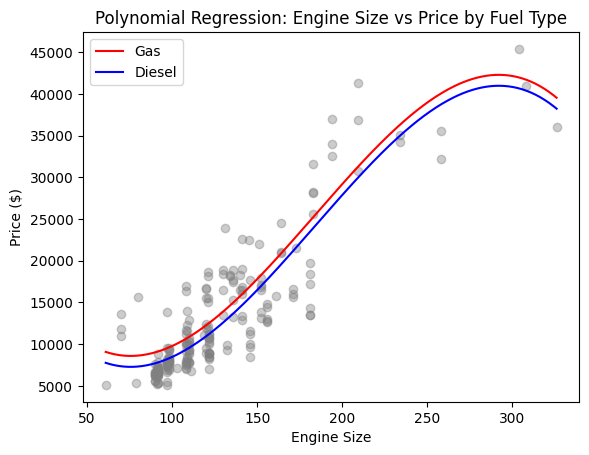

In [42]:
x_seq = np.linspace(df["engine-size"].min(), df["engine-size"].max(), 300).reshape(-1,1)
x_poly = poly.transform(x_seq)

y_gas = model.predict(np.hstack([x_poly, np.zeros((300,1))]))
y_diesel = model.predict(np.hstack([x_poly, np.ones((300,1))]))

plt.plot(x_seq, y_gas, label="Gas", color='red')
plt.plot(x_seq, y_diesel, label="Diesel", color='blue')
plt.scatter(df["engine-size"], df["price"], alpha=0.4, color='gray')
plt.xlabel("Engine Size")
plt.ylabel("Price ($)")
plt.legend()
plt.title("Polynomial Regression: Engine Size vs Price by Fuel Type")
plt.show()
